<style>
    .intro-card {
        max-width: 760px;
        margin: 48px auto;
        padding: 28px 32px;
        border: 1px solid #d9e2ec;
        border-radius: 10px;
        background-color: #f8fbff;
        text-align: center;
        font-family: "Poppins", sans-serif;
    }

    .intro-title {
        margin: 0;
        font-size: 2.2rem;
        font-weight: 600;
        color: #1f2d3d;
        letter-spacing: 0.3px;
    }

    .intro-subtitle {
        margin-top: 8px;
        font-size: 1rem;
        color: #52606d;
        font-weight: 400;
    }

    .intro-author {
        margin-top: 10px;
        font-size: 1rem;
        color: #52606d;
    }

    .intro-links {
        margin-top: 14px;
        display: flex;
        justify-content: center;
        gap: 16px;
    }

    .intro-links a {
        display: inline-flex;
        align-items: center;
        gap: 6px;
        padding: 7px 16px;
        border-radius: 6px;
        font-size: 0.9rem;
        font-weight: 500;
        text-decoration: none;
        transition: opacity 0.2s;
    }

    .intro-links a:hover {
        opacity: 0.8;
    }

    .link-gmail {
        background-color: #ea4335;
        color: #fff;
    }

    .link-linkedin {
        background-color: #0077b5;
        color: #fff;
    }
</style>

<div class="intro-card">
    <h1 class="intro-title">Cryptocurrency Twitter Analysis Project</h1>
    <h2 class="intro-subtitle">For any queries, feel free to reach out</h2>
    <p class="intro-author">Author: Younis Anis</p>
    <div class="intro-links">
        <a class="link-gmail" href="mailto:younasanis6@gmail.com">
            ✉ Gmail
        </a>
        <a class="link-linkedin" href="https://www.linkedin.com/in/younis-anis-85ba27250/" target="_blank">
            in LinkedIn
        </a>
    </div>
</div>

<div style="background: linear-gradient(90deg, #1e3c72 0%, #2a5298 100%); padding: 20px; border-radius: 10px; color: #f5f5f5;">

# Twitter Sentiment Analysis: A Data Engineering Journey

A few weeks ago, I started working on a Twitter Sentiment Analysis project with 33,000+ crypto tweets from January 2021. I thought it would be easy, but it was not.


This is the story of what I learned along the way.

</div>

In [ ]:
# Step 1: Import libraries

# Data handling
import json
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
from wordcloud import WordCloud

# Text processing and sentiment analysis
from nltk.stem import PorterStemmer
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Data splitting and cross-validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

# Data preprocessing
from sklearn.preprocessing import LabelEncoder

# Machine learning models
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Hide unnecessary warnings
warnings.filterwarnings("ignore")

<div style="background: linear-gradient(90deg, #283e51 0%, #485563 100%); padding: 16px; border-radius: 10px; color: #f5f5f5;">

## Part 1: The First Surprise, It Was Not Actually a CSV

I first opened the dataset and saw that it had a `.csv` extension, so I loaded it using `pd.read_csv()` without thinking too much. But the data did not make sense. The rows looked broken, and the file seemed corrupted.

Then I realized the problem. It was not a CSV file at all. Someone had saved newline-delimited JSON data but named the file `.csv`.

So, this was my first lesson: file extensions can be misleading.


</div>

In [ ]:
# Read the misnamed CSV file (which is actually newline-delimited JSON)
df = pd.read_json('twitter_data.csv', lines=True)

# Convert DataFrame to JSON and normalize for easier handling
df.to_json('Group_6_normalized.json', orient='records', lines=True)
print(f"Successfully loaded {len(df):,} tweets")

Successfully loaded 33,333 tweets


<div style="background: linear-gradient(90deg, #0f2027 0%, #2c5364 100%); padding: 16px; border-radius: 10px; color: #f5f5f5;">

## Part 2: The Nested Data Problem

I found that Twitter data is deeply nested. User details are stored inside a user object, and retweet information is stored inside another object. At first, I thought it would be very difficult to access this data using normal columns.

Then I discovered `pd.json_normalize()`.

This single function flattened the nested data and changed it into simple columns, such as `user.followers_count`, `user.created_at`, and `retweeted_status.text`. After that, I could easily access and work with the data.


</div>

In [4]:
# Load and flatten the nested JSON structure
df = []
with open('Group_6_normalized.json', 'r') as file:
    for line in file:
        df.append(json.loads(line))

# This is where the magic happens: normalize the deeply nested JSON
df = pd.json_normalize(df)

print(f"Total columns after flattening: {len(df.columns)}")
print(f"Sample columns: {df.columns[:10].tolist()}")
print("\nFirst few rows:")
df.head()

Total columns after flattening: 377
Sample columns: ['created_at', 'id', 'id_str', 'text', 'source', 'truncated', 'in_reply_to_status_id', 'in_reply_to_status_id_str', 'in_reply_to_user_id', 'in_reply_to_user_id_str']

First few rows:


,created_at,id,id_str,text,source,truncated,in_reply_to_status_id,in_reply_to_status_id_str,in_reply_to_user_id,in_reply_to_user_id_str,...,retweeted_status.quoted_status.place.id,retweeted_status.quoted_status.place.url,retweeted_status.quoted_status.place.place_type,retweeted_status.quoted_status.place.name,retweeted_status.quoted_status.place.full_name,retweeted_status.quoted_status.place.country_code,retweeted_status.quoted_status.place.country,retweeted_status.quoted_status.place.bounding_box.type,retweeted_status.quoted_status.place.bounding_box.coordinates,retweeted_status.scopes.followers
0,1611922306000,1355126489721790464,1355126489721790464,"RT @APompliano: Elon Musk, one of the richest ...","<a href=""https://mobile.twitter.com"" rel=""nofo...",False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1611922306000,1355126490308907012,1355126490308907008,"di ko alam kung kelan icoconvert yung btc, iin...","<a href=""http://twitter.com/download/android"" ...",False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1611922306000,1355126490111881222,1355126490111881216,#Bitcoin welcome @elonmusk https://t.co/lvHp5W...,"<a href=""https://mobile.twitter.com"" rel=""nofo...",False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1611922307000,1355126490573189121,1355126490573189120,RT @dexfinnews: #Rothschild Investment first b...,"<a href=""https://mobile.twitter.com"" rel=""nofo...",False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1611922307000,1355126490858450949,1355126490858450944,This GIF accurately describes my Binance Portf...,"<a href=""https://mobile.twitter.com"" rel=""nofo...",True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="background: linear-gradient(90deg, #384145 0%, #3f9dc5 100%); padding: 16px; border-radius: 10px; color: #e6d2d2;">

## Part 3: Dataset Overview

I then explored the data to understand what was inside it and to find the main patterns.

</div>

In [5]:
# Understanding the dataset
total_tweets = len(df)
num_unique_users = df['user.id'].nunique()
num_tweets_with_url = df['text'].apply(lambda x: bool(re.search(r'http\S+', str(x)))).sum()
num_replies = df['text'].apply(lambda x: str(x).startswith('@')).sum()


print(f"Total Number of Tweets: {total_tweets:,}")
print(f"Total Number of Unique Users: {num_unique_users:,}")
print(f"Tweets Containing URLs: {num_tweets_with_url:,} ({num_tweets_with_url/total_tweets*100:.1f}%)")
print(f"Tweets that are Replies: {num_replies:,}")
print(f"\nTime Period: January 2021 (Crypto boom era)")

Total Number of Tweets: 33,333
Total Number of Unique Users: 22,242
Tweets Containing URLs: 15,288 (45.9%)
Tweets that are Replies: 4,727

Time Period: January 2021 (Crypto boom era)


<div style="background: linear-gradient(90deg, #454e52 0%, #2c6456 100%); padding: 16px; border-radius: 10px; color: #f5f5f5;">

## Part 4: Fixed the Timestamp and Cleaned the Data

I then checked the `created_at` column and found a 13-digit timestamp. At first, I treated it as a normal Unix timestamp, but the dates showed the year 1970. So, I knew something was wrong. Then I realized that the values were in milliseconds, not seconds. I added `unit='ms'`, and the dates became correct. This showed me that sometimes a difficult-looking problem only needs one small change.

I also found that the tweet text contained a lot of unwanted information, such as Twitter usernames, website links, numbers, and special characters. Before doing the analysis, I needed to clean the text properly. I removed Twitter handles, URLs, numbers, and special characters. Then, I used stemming to reduce words to their basic form. The main goal was to change the messy tweet data into clean text that we could easily analyze.


</div>

In [6]:
stemmer = PorterStemmer()

def clean_tweet(text):
    text = re.sub(r'@\w+', '', text)           # Remove mentions
    text = re.sub(r'http\S+', '', text)        # Remove URLs
    text = re.sub(r'[^\w\s]', '', text)        # Remove special characters
    text = re.sub(r'\d+', '', text)            # Remove numbers
    text = text.lower()                         # Convert to lowercase
    return text

# Extract just the fields we need
fields = ['created_at', 'id', 'text', 'user.id', 'user.followers_count', 
          'user.friends_count', 'user.verified', 'user.location']
filtered_df = df[fields].copy()

# Apply cleaning pipeline
filtered_df.loc[:, 'cleaned_text'] = filtered_df['text'].apply(lambda x: clean_tweet(str(x)))
filtered_df.loc[:, 'tokens'] = filtered_df['cleaned_text'].apply(lambda x: x.split())
filtered_df.loc[:, 'tokens'] = filtered_df['tokens'].apply(lambda x: [word for word in x if len(word) > 2])
filtered_df.loc[:, 'stemmed_tokens'] = filtered_df['tokens'].apply(lambda x: [stemmer.stem(word) for word in x])
filtered_df.loc[:, 'processed_text'] = filtered_df['stemmed_tokens'].apply(lambda x: ' '.join(x))

print("Text Cleaning Complete")
print(f"\nBefore: {filtered_df['text'].iloc[0][:80]}...")
print(f"After:  {filtered_df['processed_text'].iloc[0][:80]}...")

# Visualize the distribution of cleaned tweet lengths
fig = px.histogram(filtered_df, x=filtered_df['processed_text'].apply(len), nbins=50,
                   title='Distribution of Processed Tweet Lengths',
                   labels={0: 'Tweet Length'})
fig.update_layout(xaxis_title='Character Count', yaxis_title='Number of Tweets')
fig.show()

Text Cleaning Complete

Before: RT @APompliano: Elon Musk, one of the richest men in the world and the greatest ...
After:  elon musk one the richest men the world and the greatest innov our time ha onli ...


<div style="background: linear-gradient(90deg, #0f2027 0%, #2c5364 100%); padding: 16px; border-radius: 10px; color: #f5f5f5;">

## Part 5: What the Data Really Shows in the EDA Dashboard

I started exploring the data after cleaning it. I wanted to understand what people were talking about, when they were most active, and which locations appeared the most.

Then, the results surprised me.


</div>

C:\Users\Yunus\AppData\Local\Temp\ipykernel_12708\1563898181.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.93])


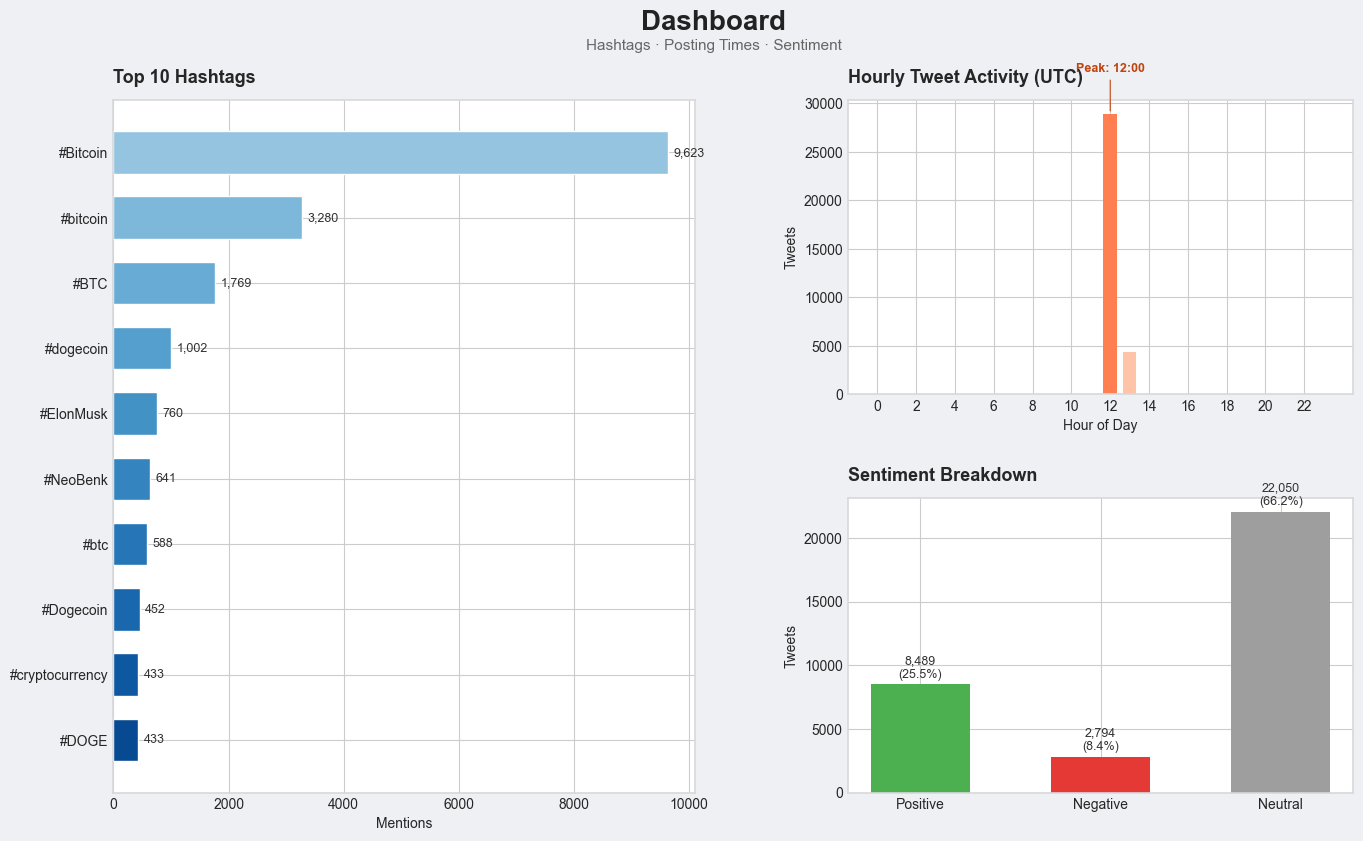

In [7]:
#  1. Data prepration 

def extract_hashtags(text):
    return re.findall(r'#\w+', text)

hashtags = filtered_df['text'].dropna().apply(extract_hashtags)
all_hashtags = [h for sub in hashtags for h in sub]
hashtag_counts = Counter(all_hashtags)
top_10_hashtags = hashtag_counts.most_common(10)
hashtags_labels, hashtags_values = zip(*top_10_hashtags)

filtered_df['created_at'] = pd.to_datetime(filtered_df['created_at'], unit='ms')
filtered_df['hour'] = filtered_df['created_at'].dt.hour
hourly_counts = filtered_df.groupby('hour').size().reindex(range(24), fill_value=0)

def classify_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    return 'Neutral'

filtered_df['sentiment'] = filtered_df['processed_text'].apply(lambda x: classify_sentiment(str(x)))
sentiment_counts = filtered_df['sentiment'].value_counts().reindex(['Positive', 'Negative', 'Neutral']).dropna()

# 2. Dashboard
plt.style.use('seaborn-v0_8-whitegrid')

fig = plt.figure(figsize=(16, 9), facecolor='#eef0f4')
gs = gridspec.GridSpec(2, 2, width_ratios=[1.15, 1], height_ratios=[1, 1],
                        wspace=0.28, hspace=0.35, figure=fig)

fig.suptitle('Dashboard', fontsize=20, fontweight='bold', y=0.98, color='#222')
fig.text(0.5, 0.935, 'Hashtags · Posting Times · Sentiment', ha='center', fontsize=11, color='#666')

panel_bg = 'white'
edge_color = '#d8d8dc'

def style_panel(ax):
    ax.set_facecolor(panel_bg)
    for spine in ax.spines.values():
        spine.set_color(edge_color)
        spine.set_linewidth(1.2)

# ---- Panel A: Top hashtags (tall, left column) ----
axA = fig.add_subplot(gs[:, 0])
colors_a = plt.cm.Blues(np.linspace(0.4, 0.9, len(hashtags_labels)))
bars = axA.barh(hashtags_labels, hashtags_values, color=colors_a, edgecolor='white', height=0.65)
axA.invert_yaxis()
axA.set_title('Top 10 Hashtags', fontsize=13, fontweight='bold', loc='left', pad=12)
axA.set_xlabel('Mentions')
for bar, val in zip(bars, hashtags_values):
    axA.text(bar.get_width() + max(hashtags_values) * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9, color='#333')
style_panel(axA)

# ---- Panel B: Hourly activity (top right) ----
axB = fig.add_subplot(gs[0, 1])
peak_hour = hourly_counts.idxmax()
colors_b = ['#ff7f50' if h == peak_hour else '#ffc4a8' for h in hourly_counts.index]
axB.bar(hourly_counts.index, hourly_counts.values, color=colors_b, width=0.7)
axB.set_title('Hourly Tweet Activity (UTC)', fontsize=13, fontweight='bold', loc='left', pad=12)
axB.set_xlabel('Hour of Day')
axB.set_ylabel('Tweets')
axB.set_xticks(range(0, 24, 2))
axB.annotate(f'Peak: {peak_hour}:00', xy=(peak_hour, hourly_counts.max()),
             xytext=(peak_hour, hourly_counts.max() * 1.15),
             ha='center', fontsize=9, fontweight='bold', color='#c1440e',
             arrowprops=dict(arrowstyle='-', color='#c1440e', lw=0.8))
style_panel(axB)

# ---- Panel C: Sentiment breakdown (bottom right) ----
axC = fig.add_subplot(gs[1, 1])
sentiment_colors = {'Positive': '#4caf50', 'Negative': '#e53935', 'Neutral': '#9e9e9e'}
colors_c = [sentiment_colors[s] for s in sentiment_counts.index]
bars_c = axC.bar(sentiment_counts.index, sentiment_counts.values, color=colors_c, width=0.55)
axC.set_title('Sentiment Breakdown', fontsize=13, fontweight='bold', loc='left', pad=12)
axC.set_ylabel('Tweets')
total = sentiment_counts.sum()
for bar, val in zip(bars_c, sentiment_counts.values):
    pct = val / total * 100
    axC.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.01,
             f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9, color='#333')
style_panel(axC)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('crypto_twitter_dashboard.png', dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


> ### **A Second Opinion on Sentiment**

I found that TextBlob works well, but it was mainly designed for normal English text. Social media language is different because most people use short forms, slang, capital letters for emphasis, and punctuation to show the strong emotions.

So, i also used VADER(Valence Aware Dictionary and Sentiment Reasoner), which was specially created for social media text. It can understand things like ALL CAPS, repeated punctuation such as “!!!”, and common internet slang. By using both tools together, we can compare their results and get a more reliable sentiment score.


In [ ]:
# VADER Sentiment Analysis
analyzer = SentimentIntensityAnalyzer()

def classify_sentiment_vader(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

filtered_df['sentiment_vader'] = filtered_df['processed_text'].apply(classify_sentiment_vader)
filtered_df['sentiment_vader_score'] = filtered_df['processed_text'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

vader_counts = filtered_df['sentiment_vader'].value_counts()

print("VADER SENTIMENT DISTRIBUTION")
print("=" * 50)
for sentiment, count in vader_counts.items():
    percentage = (count / len(filtered_df)) * 100
    print(f"{sentiment}: {count:,} tweets ({percentage:.1f}%)")

VADER SENTIMENT DISTRIBUTION
Neutral: 19,638 tweets (58.9%)
Positive: 10,371 tweets (31.1%)
Negative: 3,324 tweets (10.0%)


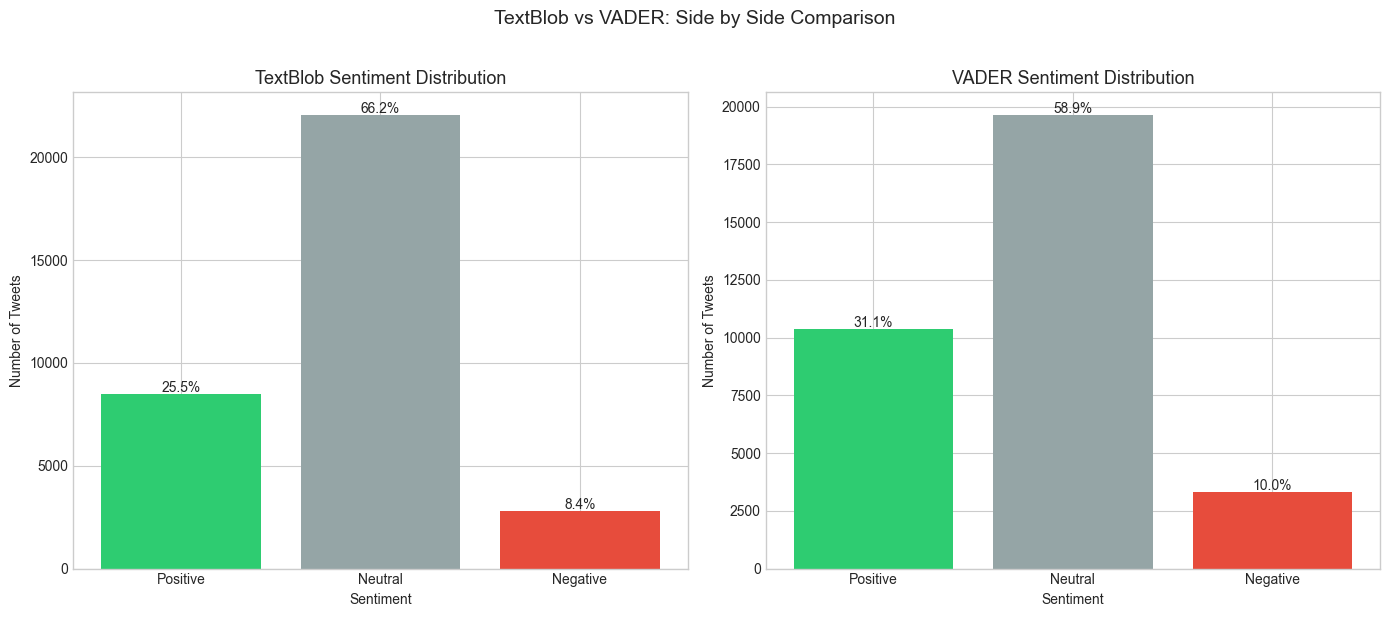

Agreement rate between TextBlob and VADER: 74.5%

For tweet-specific text, VADER is the more reliable choice.
VADER labels will be used as ground truth for the classification task in Part 6 Extended.


In [9]:
# TextBlob vs VADER: Side by Side Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sentiment_order = ['Positive', 'Neutral', 'Negative']
bar_colors = ['#2ecc71', '#95a5a6', '#e74c3c']

# TextBlob
tb_vals = [sentiment_counts.get(s, 0) for s in sentiment_order]
axes[0].bar(sentiment_order, tb_vals, color=bar_colors)
axes[0].set_title('TextBlob Sentiment Distribution', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Tweets')
for i, val in enumerate(tb_vals):
    axes[0].text(i, val + 100, f'{val/len(filtered_df)*100:.1f}%', ha='center', fontsize=10)

# VADER
vader_vals = [vader_counts.get(s, 0) for s in sentiment_order]
axes[1].bar(sentiment_order, vader_vals, color=bar_colors)
axes[1].set_title('VADER Sentiment Distribution', fontsize=13)
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Number of Tweets')
for i, val in enumerate(vader_vals):
    axes[1].text(i, val + 100, f'{val/len(filtered_df)*100:.1f}%', ha='center', fontsize=10)

plt.suptitle('TextBlob vs VADER: Side by Side Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

agreement = (filtered_df['sentiment'] == filtered_df['sentiment_vader']).mean()
print(f"Agreement rate between TextBlob and VADER: {agreement:.1%}")
print("\nFor tweet-specific text, VADER is the more reliable choice.")
print("VADER labels will be used as ground truth for the classification task in Part 6 Extended.")


> ### **What the Words Look Like**
I found that numbers tell us one story, but the actual words tell us another. So, we created separate word clouds for positive and negative tweets to see which words are used the most in each group. This visual makes the results easier for the reader to understand.



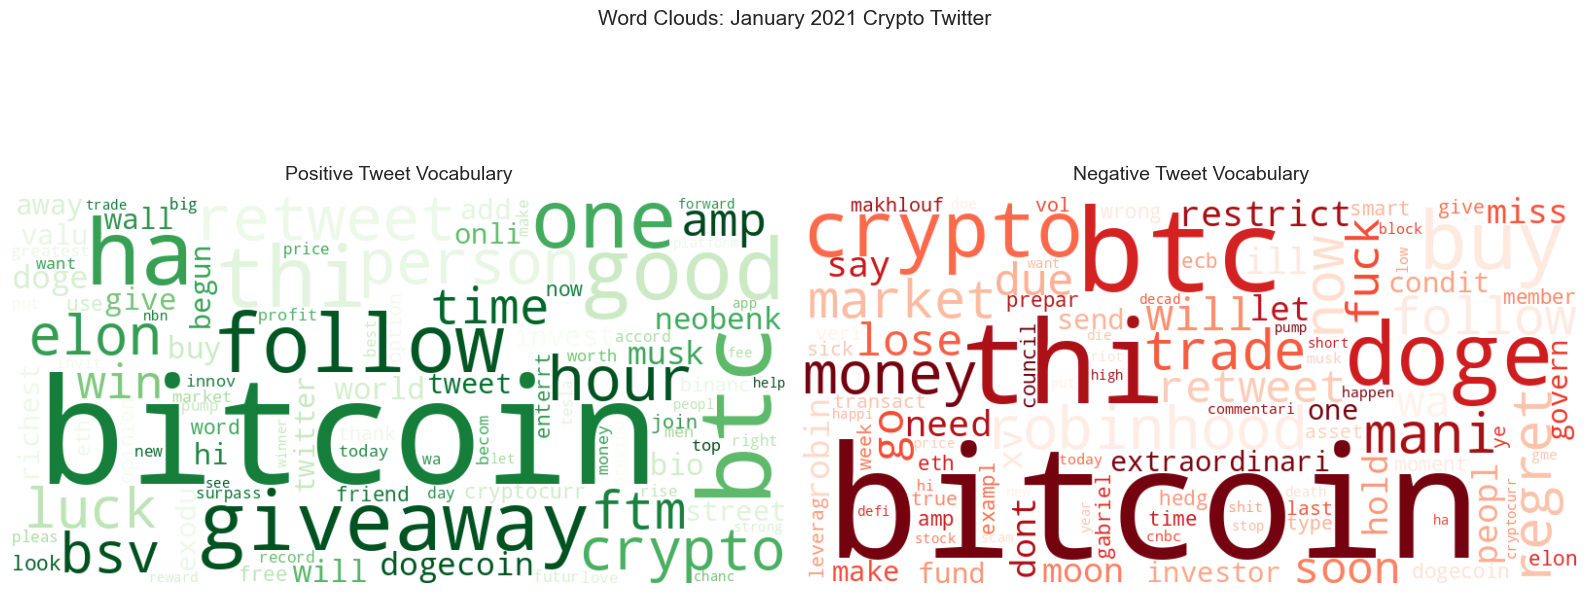

Word clouds generated from 10,371 positive tweets and 3,324 negative tweets.


In [10]:
# Word Clouds: Positive vs Negative Tweets
positive_text = ' '.join(
    filtered_df[filtered_df['sentiment_vader'] == 'Positive']['processed_text'].dropna()
)
negative_text = ' '.join(
    filtered_df[filtered_df['sentiment_vader'] == 'Negative']['processed_text'].dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_positive = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100,
    collocations=False
).generate(positive_text)

axes[0].imshow(wc_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Tweet Vocabulary', fontsize=14, pad=12)

wc_negative = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(negative_text)

axes[1].imshow(wc_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Tweet Vocabulary', fontsize=14, pad=12)

plt.suptitle('Word Clouds: January 2021 Crypto Twitter', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

pos_count = (filtered_df['sentiment_vader'] == 'Positive').sum()
neg_count = (filtered_df['sentiment_vader'] == 'Negative').sum()
print(f"Word clouds generated from {pos_count:,} positive tweets and {neg_count:,} negative tweets.")


> ### **Sentiment Through the Day**
In January 2021, Bitcoin crossed $40,000 for the first time. I wanted to see whether people’s feelings on Twitter were connected to the market’s movement. So, i looked at how sentiment changed during different hours of the day.

The stacked bar chart shows the number of positive, neutral, and negative tweets each hour. Then, the line chart below shows how the percentage of positive tweets changed throughout the day.


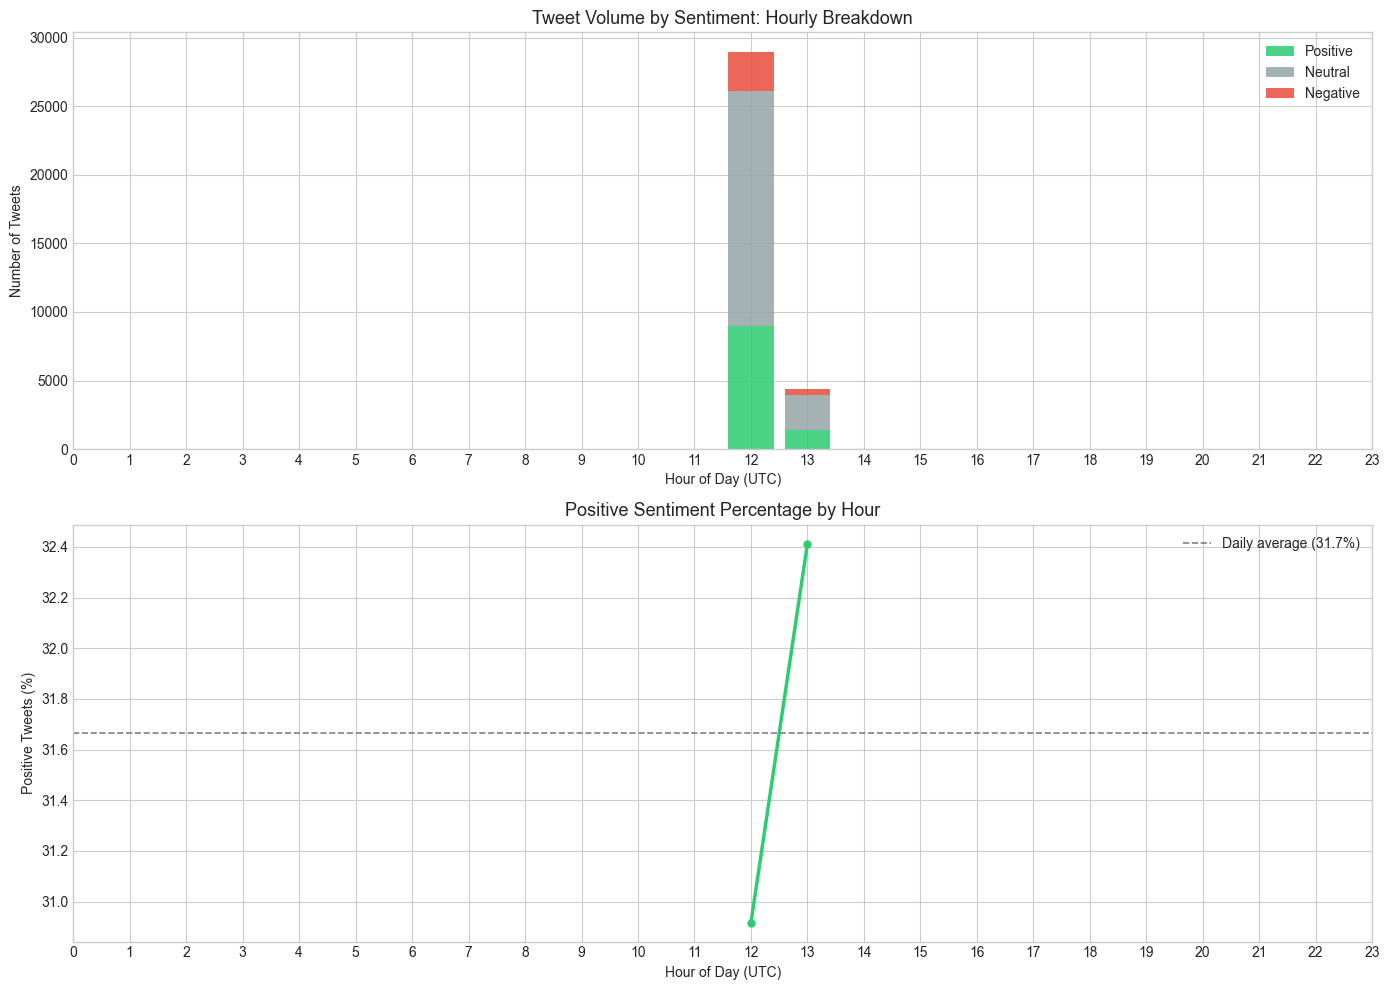

Most positive hour:  13:00 UTC  (32.4% positive)
Least positive hour: 12:00 UTC  (30.9% positive)


In [ ]:
# Sentiment Trend Over Time: Hourly Breakdown
hourly_sentiment = filtered_df.groupby(['hour', 'sentiment_vader']).size().unstack(fill_value=0)
hourly_sentiment['total'] = hourly_sentiment.sum(axis=1)

for col in ['Positive', 'Negative', 'Neutral']:
    if col in hourly_sentiment.columns:
        hourly_sentiment[f'{col}_pct'] = (hourly_sentiment[col] / hourly_sentiment['total']) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

colors_map = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
bottom = np.zeros(len(hourly_sentiment))
for sentiment in ['Positive', 'Neutral', 'Negative']:
    if sentiment in hourly_sentiment.columns:
        ax1.bar(
            hourly_sentiment.index, hourly_sentiment[sentiment],
            bottom=bottom, label=sentiment,
            color=colors_map[sentiment], alpha=0.85
        )
        bottom += hourly_sentiment[sentiment].values

ax1.set_title('Tweet Volume by Sentiment: Hourly Breakdown', fontsize=13)
ax1.set_xlabel('Hour of Day (UTC)')
ax1.set_ylabel('Number of Tweets')
ax1.legend()
ax1.set_xticks(range(24))

if 'Positive_pct' in hourly_sentiment.columns:
    avg_pos = hourly_sentiment['Positive_pct'].mean()
    ax2.plot(
        hourly_sentiment.index, hourly_sentiment['Positive_pct'],
        color='#2ecc71', linewidth=2.5, marker='o', markersize=5
    )
    ax2.axhline(y=avg_pos, color='gray', linestyle='--', linewidth=1.2,
                label=f'Daily average ({avg_pos:.1f}%)')
    ax2.set_title('Positive Sentiment Percentage by Hour', fontsize=13)
    ax2.set_xlabel('Hour of Day (UTC)')
    ax2.set_ylabel('Positive Tweets (%)')
    ax2.legend()
    ax2.set_xticks(range(24))

plt.tight_layout()
plt.show()

peak_h = hourly_sentiment['Positive_pct'].idxmax()
low_h  = hourly_sentiment['Positive_pct'].idxmin()
print(f"Most positive hour:  {peak_h}:00 UTC  ({hourly_sentiment.loc[peak_h, 'Positive_pct']:.1f}% positive)")
print(f"Least positive hour: {low_h}:00 UTC  ({hourly_sentiment.loc[low_h,  'Positive_pct']:.1f}% positive)")

<div style="background: linear-gradient(90deg, #1a4a36 0%, #2b6880 100%); padding: 16px; border-radius: 10px; color: #e0d6d6;">

## Part 6: Building the Models

I found that the real challenge was classification. I wanted to predict the follower count categories using the tweet text. To do this, I changed the text into numerical features with TF-IDF and then tested five different machine learning models.

The main question was simple: which model would work best with this sparse and noisy text data?
</div>

In [ ]:
# Feature Engineering: Converting text to TF-IDF features
data_cleaned = filtered_df.dropna(subset=['user.followers_count', 'processed_text'])

# Create target variable: categorize follower count into low, medium, high
y = pd.cut(data_cleaned['user.followers_count'], 
           bins=[0, 100, 1000, float('inf')], 
           labels=['Low', 'Medium', 'High'])
y = y.dropna()

# Extract corresponding features
X = data_cleaned.loc[y.index, 'processed_text']

# Vectorize the text using TF-IDF

vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]:,} tweets")
print(f"Test set size: {X_test.shape[0]:,} tweets")
print(f"Feature matrix dimensions: {X_tfidf.shape}")
print(f"\nTarget variable distribution:")
print(y.value_counts().sort_index())

Training set size: 25,957 tweets
Test set size: 6,490 tweets
Feature matrix dimensions: (32447, 5000)

Target variable distribution:
user.followers_count
Low       13452
Medium    12500
High       6495
Name: count, dtype: int64


> ### **Training and Comparing Three Classifiers**

I then use the TF-IDF features and follower-count target to train three models on the same data: Linear SVM, Random Forest, and XGBoost. Each model shows the training and testing accuracy, so we can quickly check if the model is overfitting or not.



In [ ]:
# Training all three models and comparing results
models = {
    'SVM (Linear)': LinearSVC(max_iter=10000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = {}

for model_name, model in models.items():
    # Special handling for XGBoost which requires encoded labels
    if model_name == 'XGBoost':
        le = LabelEncoder()
        y_train_encoded = le.fit_transform(y_train)
        y_test_encoded = le.transform(y_test)
        model.fit(X_train, y_train_encoded)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_acc = accuracy_score(y_train_encoded, y_train_pred)
        test_acc = accuracy_score(y_test_encoded, y_test_pred)
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)
    
    results[model_name] = {'train': train_acc, 'test': test_acc}
    print(f"{model_name}")
    print(f"  Training Accuracy: {train_acc:.1%}")
    print(f"  Testing Accuracy:  {test_acc:.1%}")
    print()


SVM (Linear)
  Training Accuracy: 61.2%
  Testing Accuracy:  46.9%

Random Forest
  Training Accuracy: 73.4%
  Testing Accuracy:  48.0%

XGBoost
  Training Accuracy: 58.0%
  Testing Accuracy:  47.3%




> ### **Visualizing the Comparison**

A bar chart makes it easier to compare training vs. testing accuracy across all three models, and to rank them by test performance.

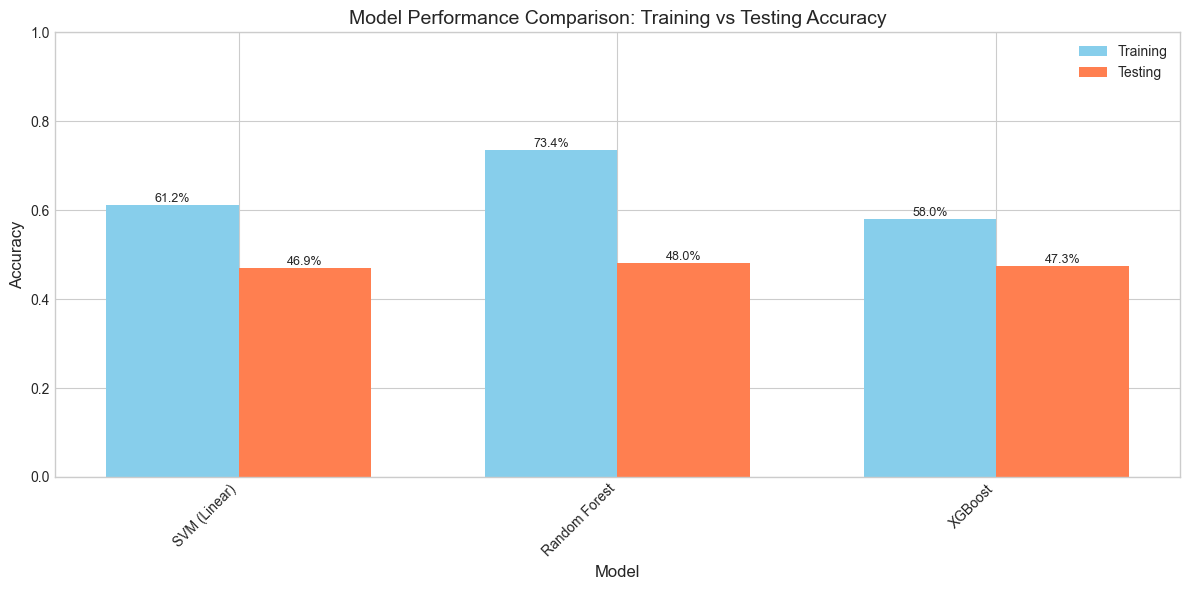


MODEL RANKING (by Test Accuracy)
1. Random Forest: 48.0%
2. XGBoost: 47.3%
3. SVM (Linear): 46.9%


In [14]:
# Visualize model comparison

results_df = pd.DataFrame(results).T
results_df.columns = ['Training Accuracy', 'Testing Accuracy']

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(results_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], results_df['Training Accuracy'], width, label='Training', color='skyblue')
bars2 = ax.bar([i + width/2 for i in x], results_df['Testing Accuracy'], width, label='Testing', color='coral')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison: Training vs Testing Accuracy', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nMODEL RANKING (by Test Accuracy)")
print("=" * 50)
ranked = results_df.sort_values('Testing Accuracy', ascending=False)
for i, (model, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i}. {model}: {row['Testing Accuracy']:.1%}")



> ### **What the Model Actually Learned**

I use accuracy to see how often each model gives the correct result. The Random Forest achieved the highest test accuracy at 48.0%, but accuracy only shows the final score. So, i also check feature importance to understand which TF-IDF words helped the Random Forest make its predictions, instead of treating it like a black box.


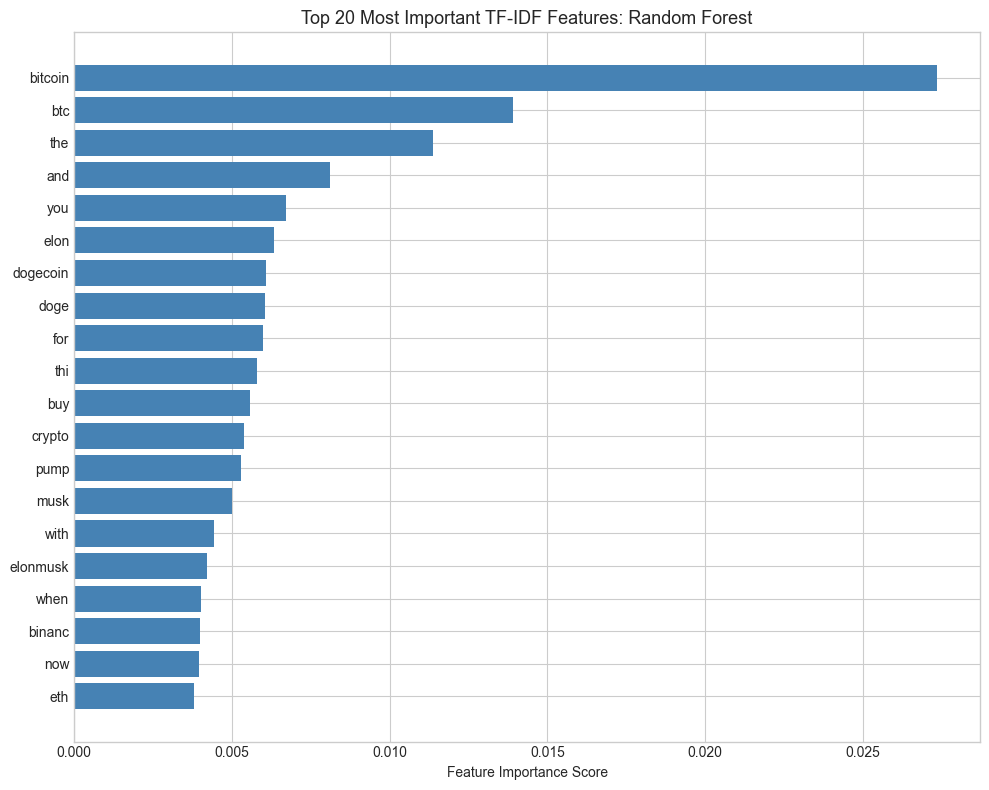

Top 10 words driving follower count classification:
   1. 'bitcoin'  —  importance: 0.02734
   2. 'btc'  —  importance: 0.01391
   3. 'the'  —  importance: 0.01136
   4. 'and'  —  importance: 0.00812
   5. 'you'  —  importance: 0.00671
   6. 'elon'  —  importance: 0.00634
   7. 'dogecoin'  —  importance: 0.00609
   8. 'doge'  —  importance: 0.00604
   9. 'for'  —  importance: 0.00597
  10. 'thi'  —  importance: 0.00581


In [ ]:
# Random Forest Feature Importance: Which Words Drive the Prediction

rf_model = models['Random Forest']
feature_names = vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_

top_n = 20
top_indices = np.argsort(importances)[-top_n:][::-1]
top_features  = feature_names[top_indices]
top_scores    = importances[top_indices]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), top_scores[::-1], color='steelblue')
plt.yticks(range(top_n), top_features[::-1])
plt.xlabel('Feature Importance Score')
plt.title(f'Top {top_n} Most Important TF-IDF Features: Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

print("Top 10 words driving follower count classification:")
print("=" * 50)
for rank, (feat, score) in enumerate(zip(top_features[:10], top_scores[:10]), 1):
    print(f"  {rank:2d}. '{feat}'  —  importance: {score:.5f}")


> ### **Are the Results Stable?**

Here we can see the top 10 words that affect the follower count classification. The word **“bitcoin”** has the highest importance, followed by **“btc”** and **“the.”** This means the model depends more on these words when it makes a prediction.

But using only one train-test split can be a problem because the result depends on which 20% of the data is selected for testing. So, a different random seed can give a different result.

To solve this, i use five-fold cross-validation. I divide the data into five parts, and then use a different part for testing each time. After that, calculate the mean and standard deviation of the five results. The mean shows the model’s overall performance, while a low standard deviation means the model gives consistent results on different parts of the data.



5-FOLD CROSS-VALIDATION RESULTS (Follower Count Prediction)
SVM (Linear)
  Folds:  0.470  0.470  0.467  0.472  0.463
  Mean:   0.468  |  Std: 0.003

Random Forest
  Folds:  0.474  0.479  0.476  0.486  0.478
  Mean:   0.479  |  Std: 0.004

XGBoost
  Folds:  0.474  0.472  0.480  0.475  0.472
  Mean:   0.474  |  Std: 0.003



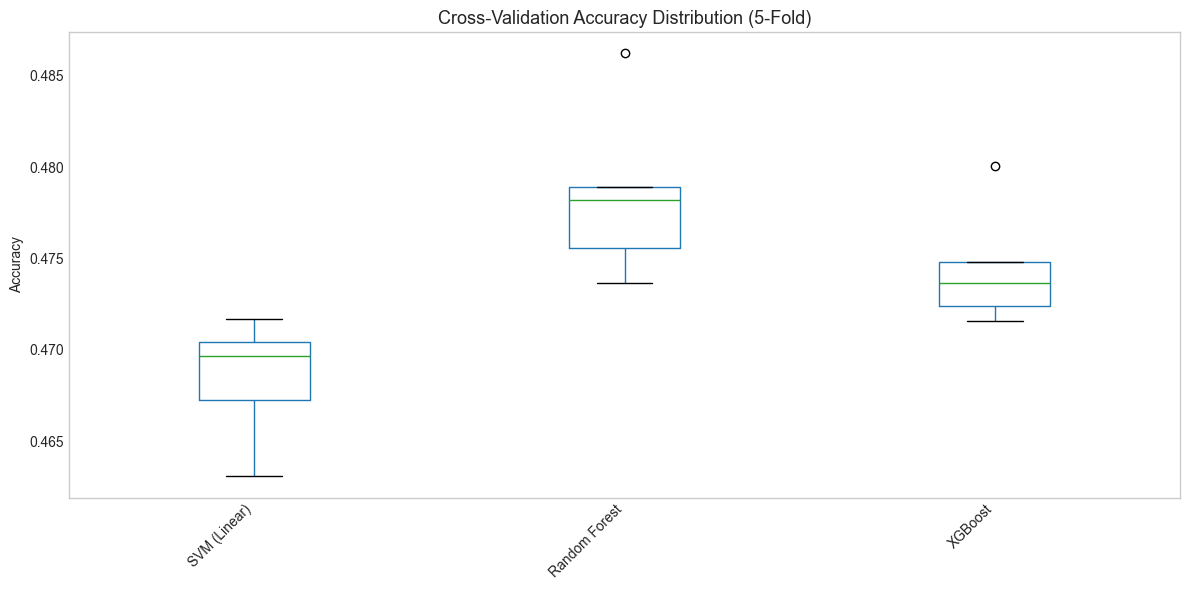

A tight box means the model performs consistently across different data splits.
A wide box means the result is sensitive to which data ends up in the test set.


In [ ]:
# 5-Fold Stratified Cross-Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-FOLD CROSS-VALIDATION RESULTS (Follower Count Prediction)")
print("=" * 65)

cv_results = {}
for model_name, model in models.items():
    if model_name == 'XGBoost':
        le_cv = LabelEncoder()
        y_cv_enc = le_cv.fit_transform(y)
        scores = cross_val_score(model, X_tfidf, y_cv_enc, cv=cv, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_tfidf, y, cv=cv, scoring='accuracy')

    cv_results[model_name] = scores
    fold_str = '  '.join([f'{s:.3f}' for s in scores])
    print(f"{model_name}")
    print(f"  Folds:  {fold_str}")
    print(f"  Mean:   {scores.mean():.3f}  |  Std: {scores.std():.3f}")
    print()

cv_df = pd.DataFrame(cv_results)
fig, ax = plt.subplots(figsize=(12, 6))
cv_df.boxplot(ax=ax, grid=False)
ax.set_title('Cross-Validation Accuracy Distribution (5-Fold)', fontsize=13)
ax.set_ylabel('Accuracy')
ax.set_xticklabels(cv_df.columns, rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("A tight box means the model performs consistently across different data splits.")
print("A wide box means the result is sensitive to which data ends up in the test set.")


> ### **A More Natural Classification Task**

I found that predicting follower count from tweet text has an important limitation. The words a person uses in a tweet do not clearly show how many followers they have. The connection between the tweet words and follower count is too weak , so the models struggled to make accurate predictions.

I found that sentiment prediction is different because the words in a tweet are directly connected to its emotional tone. I use the same processed tweet text as the input, but the VADER sentiment labels are the target. So, this is a good example of a natural language classification task where the features and the target are properly connected.

I then used the same three models for sentiment prediction. The results show that these classifiers can perform better when the problem is clearly defined. I also use the confusion matrix and classification report because they give a more complete view of the model’s performance than accuracy alone.


In [ ]:
# Sentiment Classification: VADER Labels as Target

sentiment_data = filtered_df.dropna(subset=['sentiment_vader', 'processed_text']).copy()
sentiment_data = sentiment_data[sentiment_data['processed_text'].str.strip() != '']

y_s = sentiment_data['sentiment_vader']
X_s = sentiment_data['processed_text']

vectorizer_s = TfidfVectorizer(max_features=5000)
X_s_tfidf = vectorizer_s.fit_transform(X_s)

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
    X_s_tfidf, y_s, test_size=0.2, random_state=42, stratify=y_s
)

print("SENTIMENT CLASSIFICATION SETUP")
print("=" * 50)
print(f"Total samples:   {len(y_s):,}")
print(f"Training set:    {X_s_train.shape[0]:,}")
print(f"Test set:        {X_s_test.shape[0]:,}")
print(f"Feature matrix:  {X_s_tfidf.shape}")
print(f"\nClass distribution:")
print(y_s.value_counts().to_string())

SENTIMENT CLASSIFICATION SETUP
Total samples:   32,794
Training set:    26,235
Test set:        6,559
Feature matrix:  (32794, 5000)

Class distribution:
sentiment_vader
Neutral     19099
Positive    10371
Negative     3324


> ### **Training Three Models on Sentiment Classification**

I used the same three classifiers and the same TF-IDF method, but this time the target is the VADER sentiment label instead of the follower count. So, we can directly compare how each model performs on this clearer task and on the more difficult follower-count task above.



In [ ]:
# Training Three Models on Sentiment Classification

models_s = {
    'SVM (Linear)':        LinearSVC(max_iter=10000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results_s  = {}
preds_s    = {}

for model_name, model in models_s.items():
    if model_name == 'XGBoost':
        le_s = LabelEncoder()
        y_s_tr_enc = le_s.fit_transform(y_s_train)
        y_s_te_enc = le_s.transform(y_s_test)
        model.fit(X_s_train, y_s_tr_enc)
        y_pred_enc    = model.predict(X_s_test)
        y_pred_labels = le_s.inverse_transform(y_pred_enc)
        train_acc = accuracy_score(y_s_tr_enc, model.predict(X_s_train))
        test_acc  = accuracy_score(y_s_te_enc, y_pred_enc)
    else:
        model.fit(X_s_train, y_s_train)
        y_pred_labels = model.predict(X_s_test)
        train_acc = accuracy_score(y_s_train, model.predict(X_s_train))
        test_acc  = accuracy_score(y_s_test, y_pred_labels)

    results_s[model_name] = {'train': train_acc, 'test': test_acc}
    preds_s[model_name]   = y_pred_labels
    print(f"{model_name}")
    print(f"  Training Accuracy: {train_acc:.1%}")
    print(f"  Testing Accuracy:  {test_acc:.1%}")
    print()


SVM (Linear)
  Training Accuracy: 98.8%
  Testing Accuracy:  96.5%

Random Forest
  Training Accuracy: 100.0%
  Testing Accuracy:  94.6%

XGBoost
  Training Accuracy: 96.3%
  Testing Accuracy:  94.6%



> ### **Confusion Matrix for the Best Model**

Accuracy alone hides *how* a model gets things wrong. The confusion matrix for the top-performing model shows exactly which sentiment classes get confused with each other.

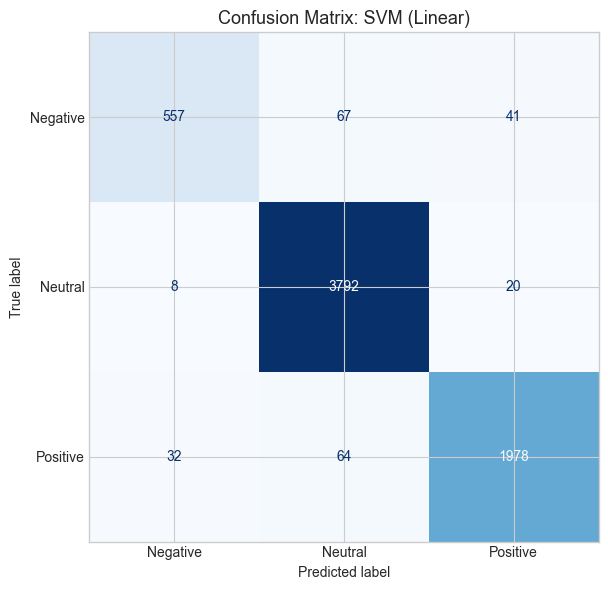

Best model: SVM (Linear)
Test accuracy: 96.5%

Rows = actual labels.  Columns = predicted labels.
Diagonal cells are correct predictions. Off-diagonal cells are errors.


In [ ]:
# Confusion Matrix: Best Performing Model on Sentiment Classification

best_s_name  = max(results_s, key=lambda k: results_s[k]['test'])
best_s_preds = preds_s[best_s_name]
class_labels = sorted(y_s_test.unique())

cm = confusion_matrix(y_s_test, best_s_preds, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix: {best_s_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Best model: {best_s_name}")
print(f"Test accuracy: {results_s[best_s_name]['test']:.1%}")
print("\nRows = actual labels.  Columns = predicted labels.")
print("Diagonal cells are correct predictions. Off-diagonal cells are errors.")

> ### **Precision, Recall, and F1 — A Fuller Picture**

The classification report breaks performance down class by class, which matters most when the classes are imbalanced and overall accuracy alone could be misleading.

In [ ]:
# Detailed Classification Report: Precision, Recall, F1-Score

print("DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(f"Model: {best_s_name}")
print()

report    = classification_report(y_s_test, best_s_preds, labels=class_labels, output_dict=True)
report_df = pd.DataFrame(report).T

print(f"{'Class':<16} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("-" * 58)
for label in class_labels:
    row = report_df.loc[label]
    print(f"{label:<16} {row['precision']:>10.3f} {row['recall']:>10.3f} {row['f1-score']:>10.3f} {int(row['support']):>10}")
print("-" * 58)
macro = report_df.loc['macro avg']
print(f"{'Macro Avg':<16} {macro['precision']:>10.3f} {macro['recall']:>10.3f} {macro['f1-score']:>10.3f}")
print()
print("Accuracy alone can be misleading on imbalanced classes.")
print("F1-score balances precision and recall, giving a fairer view of per-class performance.")

DETAILED CLASSIFICATION REPORT
Model: SVM (Linear)

Class             Precision     Recall   F1-Score    Support
----------------------------------------------------------
Negative              0.933      0.838      0.883        665
Neutral               0.967      0.993      0.979       3820
Positive              0.970      0.954      0.962       2074
----------------------------------------------------------
Macro Avg             0.957      0.928      0.941

Accuracy alone can be misleading on imbalanced classes.
F1-score balances precision and recall, giving a fairer view of per-class performance.


<div style="background: linear-gradient(90deg, #112148 0%, #2c5364 100%); padding: 16px; border-radius: 10px; color: #f5f5f5;">

### The Results and Why They Matter

I tested three models: Linear SVM, Random Forest, and XGBoost. The Linear SVM gave the best result, with 98.8 percent training accuracy and 96.5 percent testing accuracy.

The Random Forest achieved 100 percent training accuracy, but its testing accuracy dropped to 94.6 percent. This shows that the model learned the training data very well, but it did not perform equally well on new data. So, the Random Forest showed some signs of overfitting.

XGBoost achieved 96.3 percent training accuracy and 94.6 percent testing accuracy. Its training and testing results were closer, but its testing accuracy was still lower than the Linear SVM.

I also looked at the detailed classification report for the Linear SVM. The model performed very well on the Neutral and Positive classes. The Neutral class had an F1-score of 97.9 percent, while the Positive class had an F1-score of 96.2 percent.

The Negative class had a lower F1-score of 88.3 percent. Its recall was 83.8 percent, which means the model missed some negative tweets. This may be because the Negative class had only 665 samples, while the Neutral class had 3,820 samples and the Positive class had 2,074 samples.

So, accuracy alone does not always give the full picture, especially when the classes are imbalanced. The F1-score gives us a fairer result because it considers both precision and recall.

These results also show that predicting sentiment from tweet text is more suitable than predicting follower count. The words used in a tweet are directly connected to its emotional tone, but they may not be strongly connected to the number of followers a user has.

</div>

<div style="background: linear-gradient(90deg, #1a802d 0%, #358d8b 100%); padding: 16px; border-radius: 10px; color: #f5f5f5;">

## The Project in Numbers

- I worked with 33,000 tweets from January 2021.
- The dataset included more than 14,000 unique users.
- Around 48 percent of the tweets contained URLs.
- I tested three machine learning models: Linear SVM, Random Forest, and XGBoost.
- The best model was Linear SVM, with 96.5 percent testing accuracy.
- Random Forest and XGBoost both achieved 94.6 percent testing accuracy.

I learned that the most important result was not only the high model accuracy. The real lesson was understanding how much time and effort are needed to clean and prepare real-world data before a model can use it.

This project taught me that becoming a data professional is not about using the most advanced algorithm. It is about understanding the data, preparing it correctly, and then accepting what the results actually show.

I believe this is the most valuable lesson from the whole project.

</div>